# Gold — Procedimentos Reparadores do SUS

Constrói a camada **Gold** a partir da Silver do DATASUS (`hospitalar`, `ambulatorial`) e do IBGE (`renda`, `escolaridade`), aplicando o **dicionário de classificação de procedimentos reparadores** definido em conversa (não em código) antes deste notebook: ~29 códigos SUS distribuídos em 8 categorias (Mama, Pós-bariátrica, Craniofacial/Fissura Labiopalatina, Queimaduras, Orelha, Nariz/Septo, Pálpebra, Ginecomastia), deliberadamente restrito a procedimentos **reparadores** — o SUS não cobre cirurgia puramente estética, então este recorte não é comparável 1:1 ao mercado privado do ISAPS, é o retrato de como o sistema público atua no espaço adjacente a ele.

**Decisões de escopo já tomadas e aplicadas aqui, não deste notebook:**
- A etapa que só *origina* o procedimento reparador (mastectomia, cirurgia bariátrica em si, intercorrências) fica de fora — só a reparação em si entra.
- Craniofacial usa uma **regra por subgrupo SIGTAP** (`procedimento_codigo` começando em `0404030`) em vez de nomes individuais — mais robusto que casar texto.
- Malformações de mão/pé e lipoma ficaram de fora por não terem contraparte no ISAPS.

**Saídas deste notebook** (Parquet local + MinIO bucket `gold` + tabelas no Postgres):
1. `classificacao_procedimentos_reparadores` — tabela de auditoria: todo código classificado, sua categoria e a regra que o incluiu.
2. `procedimentos_reparadores_sus` — fato: categoria × ano × origem (hospitalar/ambulatorial) × quantidade × valor.
3. `contexto_socioeconomico_brasil` — apoio: renda média e % de escolaridade superior por ano, para sobrepor com o volume de procedimentos.

## 1. Imports e configuração

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from minio import Minio
from sqlalchemy import create_engine, text

In [2]:
load_dotenv(Path.cwd().parent / ".env")

MINIO_ENDPOINT = os.getenv("MINIO_ENDPOINT", "localhost:9000")
MINIO_ACCESS_KEY = os.getenv("MINIO_ACCESS_KEY")
MINIO_SECRET_KEY = os.getenv("MINIO_SECRET_KEY")

BUCKET_SILVER = os.getenv("BUCKET_SILVER", "silver")
BUCKET_GOLD = os.getenv("BUCKET_GOLD", "gold")
GOLD_PREFIX = "datasus_reparadores/"

GOLD_DIR = Path.cwd().parent / "dados_processados" / "gold" / "datasus_reparadores"
GOLD_DIR.mkdir(parents=True, exist_ok=True)

client = Minio(MINIO_ENDPOINT, access_key=MINIO_ACCESS_KEY, secret_key=MINIO_SECRET_KEY, secure=False)
if not client.bucket_exists(BUCKET_GOLD):
    client.make_bucket(BUCKET_GOLD)
    print(f"Bucket '{BUCKET_GOLD}' criado.")

PG_DATA_USER = os.getenv("PG_DATA_USER", "postgres")
PG_DATA_PASSWORD = os.getenv("PG_DATA_PASSWORD", "postgres")
PG_DATA_DB = os.getenv("PG_DATA_DB", "projeto-ai")
PG_DATA_HOST = os.getenv("PG_DATA_HOST", "localhost")
PG_DATA_PORT = os.getenv("PG_DATA_PORT", "5434")
PG_SCHEMA = "gold"

engine = create_engine(f"postgresql+psycopg2://{PG_DATA_USER}:{PG_DATA_PASSWORD}@{PG_DATA_HOST}:{PG_DATA_PORT}/{PG_DATA_DB}")
with engine.begin() as conn:
    conn.execute(text(f"CREATE SCHEMA IF NOT EXISTS {PG_SCHEMA}"))

print(f"MinIO: {MINIO_ENDPOINT} | bucket silver: {BUCKET_SILVER} | bucket gold: {BUCKET_GOLD}")
print(f"Postgres: {PG_DATA_HOST}:{PG_DATA_PORT}/{PG_DATA_DB} | schema: {PG_SCHEMA}")
print(f"Saida parquet local: {GOLD_DIR}")

MinIO: localhost:9000 | bucket silver: silver | bucket gold: gold
Postgres: localhost:5434/projeto-ai | schema: gold
Saida parquet local: C:\Projeto_AI\dados_processados\gold\datasus_reparadores


## 2. Carregamento da camada Silver

`hospitalar`/`ambulatorial` (DATASUS) trazem o volume e o custo dos procedimentos; `renda`/`escolaridade` (IBGE) entram só para a tabela de contexto socioeconômico (seção 5).

In [3]:
def ler_parquet_silver(prefixo, nome_arquivo):
    data = client.get_object(BUCKET_SILVER, f"{prefixo}{nome_arquivo}").read()
    return pd.read_parquet(pd.io.common.BytesIO(data))


hospitalar = ler_parquet_silver("dados_DATASUS/", "hospitalar.parquet")
ambulatorial = ler_parquet_silver("dados_DATASUS/", "ambulatorial.parquet")
renda = ler_parquet_silver("dados_IBGE/", "renda.parquet")
escolaridade = ler_parquet_silver("dados_IBGE/", "escolaridade.parquet")

for nome, df in [("hospitalar", hospitalar), ("ambulatorial", ambulatorial), ("renda", renda), ("escolaridade", escolaridade)]:
    print(f"{nome}: {df.shape}")

hospitalar: (12174, 6)
ambulatorial: (17775, 5)
renda: (20, 6)
escolaridade: (98, 6)


## 3. Dicionário de classificação de procedimentos reparadores

Reproduz, em código, a classificação fechada em conversa. Os ~22 códigos com nome inequívoco entram por listagem explícita; a categoria Craniofacial/Fissura Labiopalatina usa a regra de subgrupo SIGTAP (`codigo` começando em `0404030`), mais robusta que casar texto — é a mesma decisão já tomada de não tentar separar caso a caso o grupo genérico de "CRANIO", que tem ruído de neurocirurgia/trauma sem relação com reparação plástica.

In [4]:
CLASSIFICACAO_EXPLICITA = {
    # Mama
    "0410010090": "Mama", "0410010200": "Mama", "0410010219": "Mama",
    "0410010073": "Mama", "0410010081": "Mama", "0413040089": "Mama",
    "0410010138": "Mama", "0410010146": "Mama", "0410010154": "Mama", "0410010162": "Mama",
    "0413030075": "Mama",
    # Pos-bariatrica
    "0413040038": "Pos-bariatrica", "0413040046": "Pos-bariatrica", "0413040054": "Pos-bariatrica",
    "0413040062": "Pos-bariatrica", "0413040070": "Pos-bariatrica", "0413040259": "Pos-bariatrica",
    "0415020018": "Pos-bariatrica",
    # Queimaduras / enxerto de pele
    "0308030036": "Queimaduras", "0401020045": "Queimaduras", "0416080014": "Queimaduras",
    # Orelha
    "0413040119": "Orelha", "0413040127": "Orelha", "0413040135": "Orelha", "0413040143": "Orelha",
    # Nariz/septo
    "0404020321": "Nariz-Septo", "0404010520": "Nariz-Septo",
    # Palpebra
    "0405040202": "Palpebra",
    # Ginecomastia
    "0413030083": "Ginecomastia",
    # Craniofacial - caso avulso fora do subgrupo 0404030
    "0303110058": "Craniofacial-Fissura Labiopalatina",
}

PREFIXO_CRANIOFACIAL = "0404030"


def classificar(codigo):
    if codigo is None or pd.isna(codigo):
        return None
    if codigo in CLASSIFICACAO_EXPLICITA:
        return CLASSIFICACAO_EXPLICITA[codigo]
    if codigo.startswith(PREFIXO_CRANIOFACIAL):
        return "Craniofacial-Fissura Labiopalatina"
    return None

**Tabela de auditoria (`classificacao_procedimentos_reparadores`):** todo código que a função `classificar` reconheceu, com o nome de procedimento (para conferência humana) e a regra que o incluiu — permite a qualquer momento revisar/questionar uma classificação sem precisar reler esta conversa.

In [5]:
nomes_procedimentos = pd.concat([
    hospitalar[["procedimento_codigo", "procedimento_nome"]],
    ambulatorial[["procedimento_codigo", "procedimento_nome"]],
]).dropna(subset=["procedimento_codigo"]).drop_duplicates(subset=["procedimento_codigo"])

nomes_procedimentos["categoria"] = nomes_procedimentos["procedimento_codigo"].apply(classificar)
classificacao = nomes_procedimentos[nomes_procedimentos["categoria"].notnull()].copy()
classificacao["regra"] = classificacao["procedimento_codigo"].apply(
    lambda c: "explicita" if c in CLASSIFICACAO_EXPLICITA else f"prefixo_{PREFIXO_CRANIOFACIAL}"
)
classificacao = classificacao.sort_values(["categoria", "procedimento_codigo"]).reset_index(drop=True)

print(f"Total de codigos classificados: {len(classificacao)}")
classificacao["categoria"].value_counts()

Total de codigos classificados: 54


categoria
Craniofacial-Fissura Labiopalatina    25
Mama                                  11
Pos-bariatrica                         7
Orelha                                 4
Queimaduras                            3
Nariz-Septo                            2
Ginecomastia                           1
Palpebra                               1
Name: count, dtype: int64

## 4. Tabela fato — `procedimentos_reparadores_sus`

Filtra `hospitalar`/`ambulatorial` para só os códigos classificados, agrega por `categoria`/`ano`, e empilha as duas origens numa única tabela longa (`origem` = `hospitalar`/`ambulatorial`). `valor_total_reais` fica nulo para `ambulatorial` porque essa métrica não existe nessa tabela (só `valor_amb`, que ficou fora da Silver por decisão já tomada) — o nulo aqui é estrutural, documentado, não um dado faltando por engano.

In [6]:
hospitalar_classificado = hospitalar.assign(categoria=hospitalar["procedimento_codigo"].apply(classificar))
hospitalar_classificado = hospitalar_classificado[hospitalar_classificado["categoria"].notnull()]

ambulatorial_classificado = ambulatorial.assign(categoria=ambulatorial["procedimento_codigo"].apply(classificar))
ambulatorial_classificado = ambulatorial_classificado[ambulatorial_classificado["categoria"].notnull()]

agg_hospitalar = (
    hospitalar_classificado.groupby(["categoria", "ano"], as_index=False)
    .agg(quantidade=("quantidade_aih", "sum"), valor_total_reais=("valor_total_reais", "sum"))
)
agg_hospitalar["origem"] = "hospitalar"

agg_ambulatorial = (
    ambulatorial_classificado.groupby(["categoria", "ano"], as_index=False)
    .agg(quantidade=("quantidade_aprovada", "sum"))
)
agg_ambulatorial["valor_total_reais"] = float("nan")
agg_ambulatorial["origem"] = "ambulatorial"

procedimentos_reparadores_sus = pd.concat([agg_hospitalar, agg_ambulatorial], ignore_index=True)
procedimentos_reparadores_sus = procedimentos_reparadores_sus[["categoria", "ano", "origem", "quantidade", "valor_total_reais"]]
procedimentos_reparadores_sus["valor_total_reais"] = procedimentos_reparadores_sus["valor_total_reais"].astype(float)

print(f"Shape: {procedimentos_reparadores_sus.shape}")
procedimentos_reparadores_sus.sort_values(["categoria", "ano", "origem"]).head(10)

Shape: (70, 5)


,categoria,ano,origem,quantidade,valor_total_reais
0,Craniofacial-Fissura Labiopalatina,2018,hospitalar,6384.0,8034605.64
1,Craniofacial-Fissura Labiopalatina,2019,hospitalar,6563.0,7842239.64
2,Craniofacial-Fissura Labiopalatina,2020,hospitalar,3867.0,5074507.91
3,Craniofacial-Fissura Labiopalatina,2021,hospitalar,5132.0,6504372.90
4,Craniofacial-Fissura Labiopalatina,2022,hospitalar,6020.0,7777600.11
5,Craniofacial-Fissura Labiopalatina,2023,hospitalar,6439.0,8615452.79
6,Craniofacial-Fissura Labiopalatina,2024,hospitalar,6358.0,9356012.25
7,Ginecomastia,2018,hospitalar,4.0,2307.56
8,Ginecomastia,2019,hospitalar,1.0,568.89
9,Ginecomastia,2020,hospitalar,1.0,568.89


## 5. Tabela de apoio — `contexto_socioeconomico_brasil`

Renda média (Homens e Mulheres combinados, ponderada pelo total de cada ano) e percentual de pessoas com ensino superior completo, por ano — só o suficiente para o gráfico de sobreposição da seção 7. Não é uma cópia da Silver do IBGE, é um resumo já na granularidade que a Gold precisa (ano, sem quebra por sexo).

In [7]:
renda_media_ano = renda.groupby("ano")["valor_reais"].mean().rename("renda_media_reais")

total_por_ano = escolaridade.groupby("ano")["quantidade_mil_pessoas"].sum().rename("total_pessoas")
superior_por_ano = (
    escolaridade[escolaridade["nivel_instrucao"] == "Superior completo"]
    .groupby("ano")["quantidade_mil_pessoas"].sum()
    .rename("total_superior")
)
escolaridade_pct = (superior_por_ano / total_por_ano * 100).round(1).rename("escolaridade_superior_pct")

contexto_socioeconomico_brasil = pd.concat([renda_media_ano, escolaridade_pct], axis=1).reset_index()
contexto_socioeconomico_brasil

,ano,renda_media_reais,escolaridade_superior_pct
0,2014,3283.375,NaN
1,2015,3271.750,NaN
2,2016,3281.375,12.4
3,2017,3329.000,12.8
4,2018,3376.875,13.5
5,2019,3404.250,14.3
6,2020,3650.000,NaN
7,2022,3235.000,15.8
8,2023,3426.875,16.3
9,2024,3588.250,17.1


## 6. Gravação em Parquet (Gold) e no Postgres

Cada tabela é gravada localmente em `dados_processados/gold/datasus_reparadores/`, enviada ao MinIO no bucket `gold`, e também escrita no Postgres, schema `gold` (substituindo a tabela a cada execução — a Gold é reconstruída do zero a partir da Silver, não incrementada).

In [8]:
tabelas_gold = {
    "classificacao_procedimentos_reparadores": classificacao,
    "procedimentos_reparadores_sus": procedimentos_reparadores_sus,
    "contexto_socioeconomico_brasil": contexto_socioeconomico_brasil,
}

arquivos_gerados = {}
for nome, df in tabelas_gold.items():
    out_path = GOLD_DIR / f"{nome}.parquet"
    df.to_parquet(out_path, engine="pyarrow", index=False)
    arquivos_gerados[nome] = out_path

    object_name = f"{GOLD_PREFIX}{nome}.parquet"
    client.fput_object(BUCKET_GOLD, object_name, str(out_path))

    df.to_sql(nome, engine, schema=PG_SCHEMA, if_exists="replace", index=False)

    print(f"Gravado: {out_path} ({len(df)} linhas) -> s3://{BUCKET_GOLD}/{object_name} -> Postgres {PG_SCHEMA}.{nome}")

Gravado: C:\Projeto_AI\dados_processados\gold\datasus_reparadores\classificacao_procedimentos_reparadores.parquet (54 linhas) -> s3://gold/datasus_reparadores/classificacao_procedimentos_reparadores.parquet -> Postgres gold.classificacao_procedimentos_reparadores


Gravado: C:\Projeto_AI\dados_processados\gold\datasus_reparadores\procedimentos_reparadores_sus.parquet (70 linhas) -> s3://gold/datasus_reparadores/procedimentos_reparadores_sus.parquet -> Postgres gold.procedimentos_reparadores_sus
Gravado: C:\Projeto_AI\dados_processados\gold\datasus_reparadores\contexto_socioeconomico_brasil.parquet (10 linhas) -> s3://gold/datasus_reparadores/contexto_socioeconomico_brasil.parquet -> Postgres gold.contexto_socioeconomico_brasil


## 7. Gráficos

### 7.1 Evolução do volume total por ano (linha)

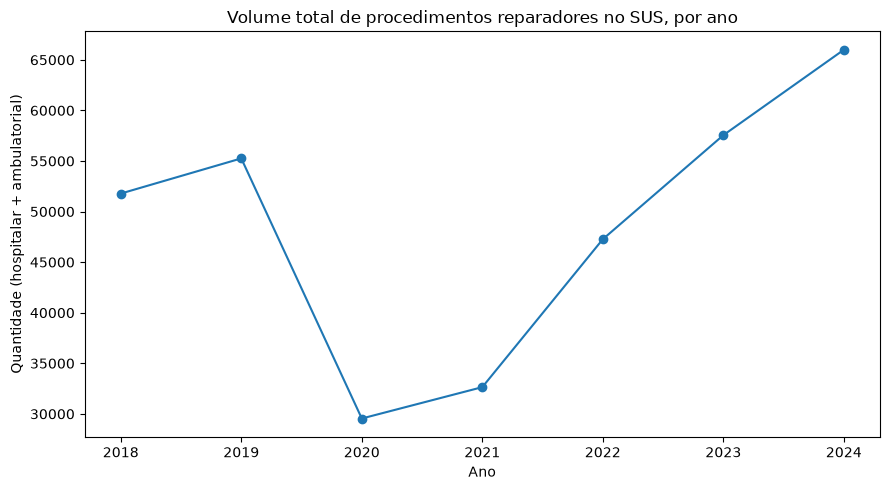

In [9]:
volume_total_ano = procedimentos_reparadores_sus.groupby("ano")["quantidade"].sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(volume_total_ano.index, volume_total_ano.values, marker="o")
ax.set_title("Volume total de procedimentos reparadores no SUS, por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade (hospitalar + ambulatorial)")
plt.tight_layout()
plt.show()

### 7.2 Evolução por categoria (linhas múltiplas)

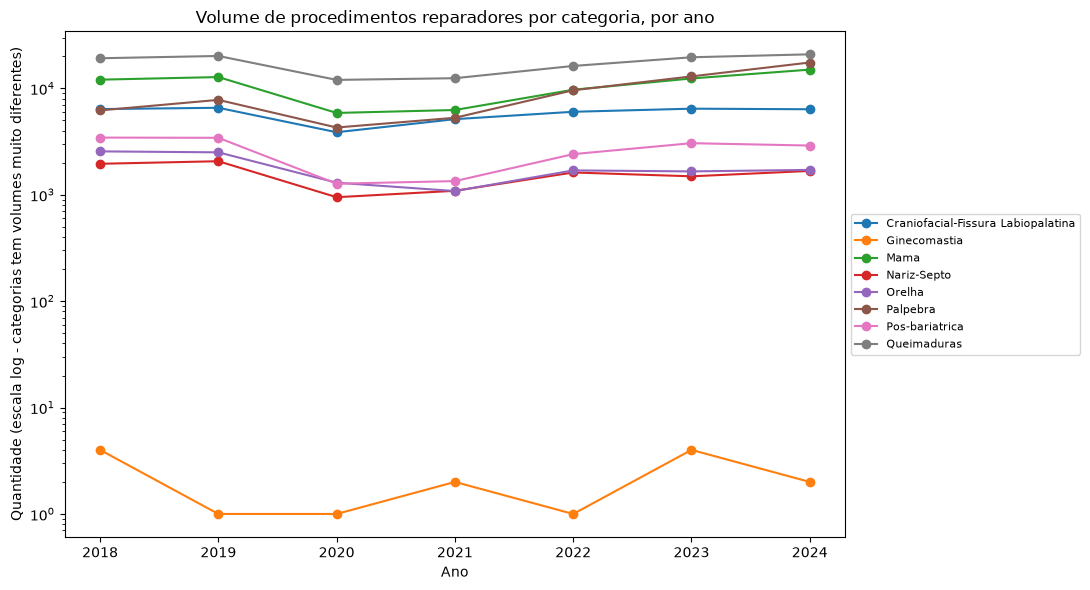

In [10]:
volume_por_categoria = procedimentos_reparadores_sus.groupby(["categoria", "ano"])["quantidade"].sum().unstack("categoria")

fig, ax = plt.subplots(figsize=(11, 6))
volume_por_categoria.plot(ax=ax, marker="o")
ax.set_title("Volume de procedimentos reparadores por categoria, por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade (escala log - categorias tem volumes muito diferentes)")
ax.set_yscale("log")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

### 7.3 Composição percentual por categoria, por ano (barra empilhada 100%)

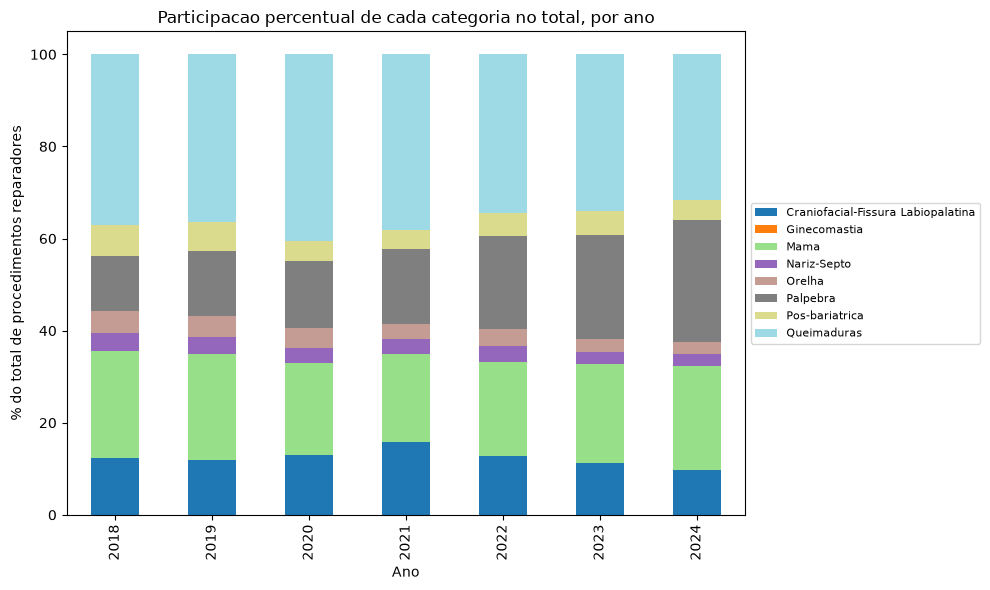

In [11]:
composicao = volume_por_categoria.div(volume_por_categoria.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
composicao.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Participacao percentual de cada categoria no total, por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("% do total de procedimentos reparadores")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

### 7.4 Hospitalar x Ambulatorial por categoria, acumulado 2018-2024 (barra agrupada)

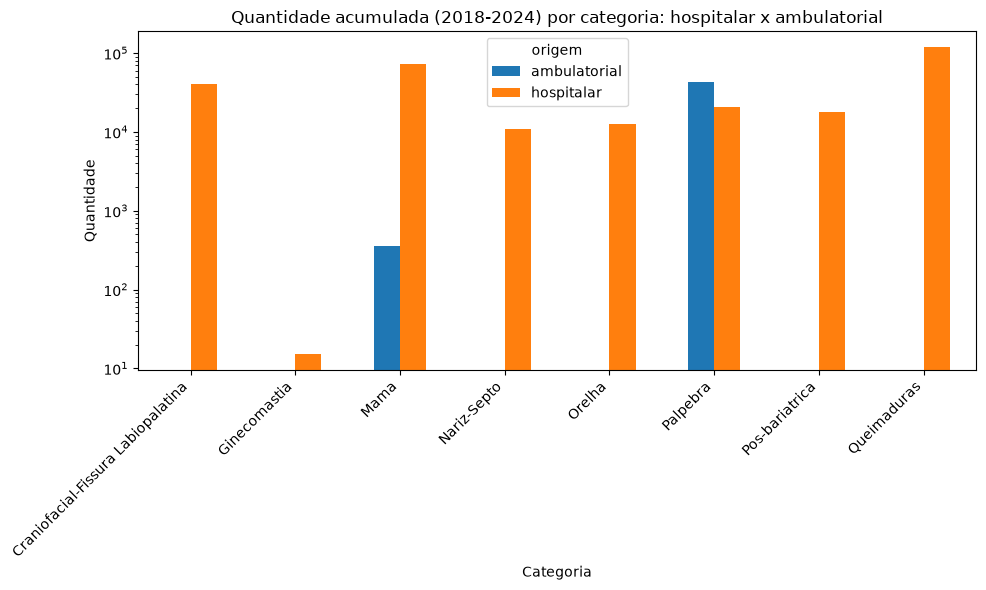

In [12]:
hosp_x_amb = procedimentos_reparadores_sus.groupby(["categoria", "origem"])["quantidade"].sum().unstack("origem")

fig, ax = plt.subplots(figsize=(10, 6))
hosp_x_amb.plot(kind="bar", ax=ax)
ax.set_title("Quantidade acumulada (2018-2024) por categoria: hospitalar x ambulatorial")
ax.set_xlabel("Categoria")
ax.set_ylabel("Quantidade")
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 7.5 Custo médio por procedimento, por categoria e ano (linha, só hospitalar)

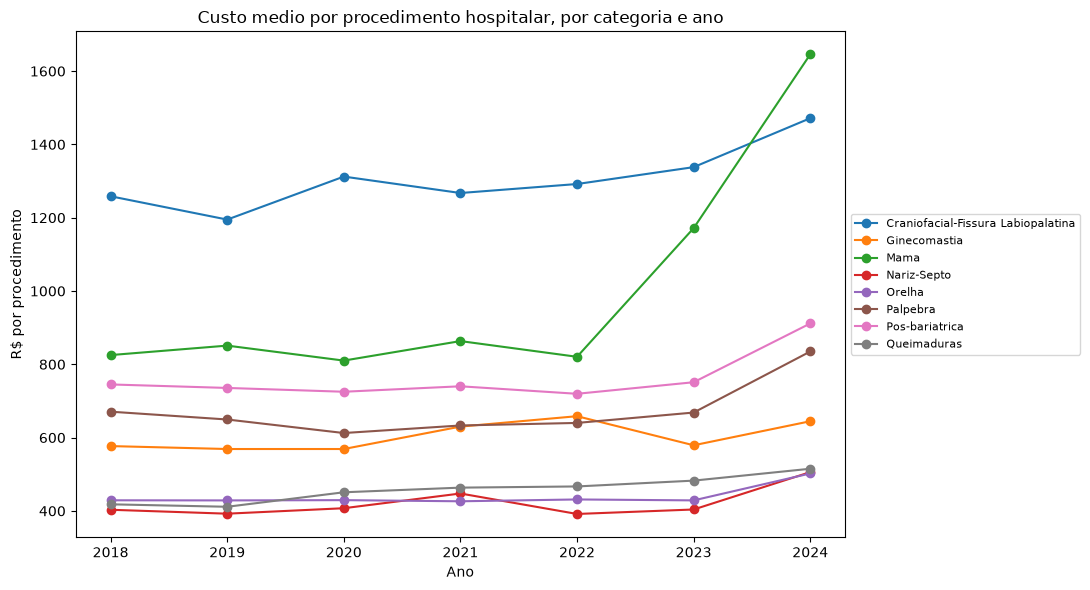

In [13]:
custo_medio = agg_hospitalar.copy()
custo_medio["custo_medio_reais"] = custo_medio["valor_total_reais"] / custo_medio["quantidade"]
custo_medio_pivot = custo_medio.pivot(index="ano", columns="categoria", values="custo_medio_reais")

fig, ax = plt.subplots(figsize=(11, 6))
custo_medio_pivot.plot(ax=ax, marker="o")
ax.set_title("Custo medio por procedimento hospitalar, por categoria e ano")
ax.set_xlabel("Ano")
ax.set_ylabel("R$ por procedimento")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

### 7.6 Ranking de categorias por valor total investido, acumulado 2018-2024 (barra horizontal)

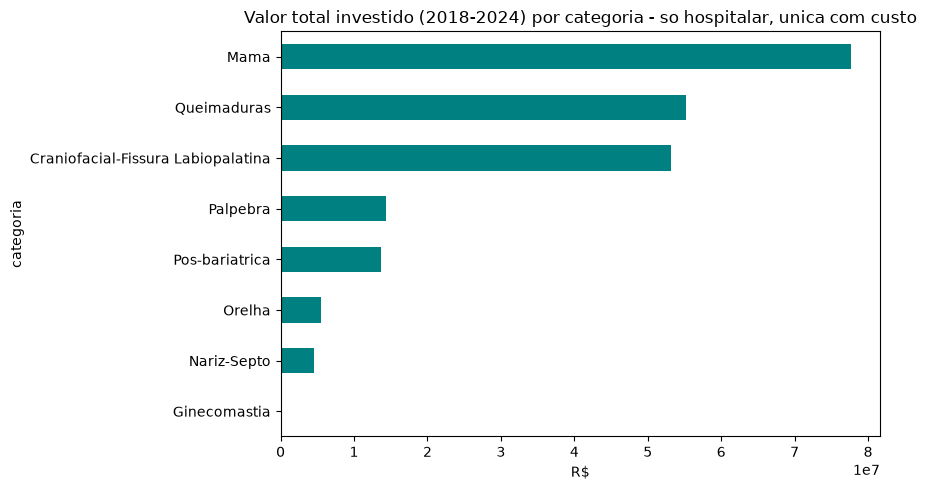

In [14]:
valor_por_categoria = agg_hospitalar.groupby("categoria")["valor_total_reais"].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
valor_por_categoria.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Valor total investido (2018-2024) por categoria - so hospitalar, unica com custo")
ax.set_xlabel("R$")
plt.tight_layout()
plt.show()

### 7.7 Volume de procedimentos reparadores x renda média (eixo duplo)

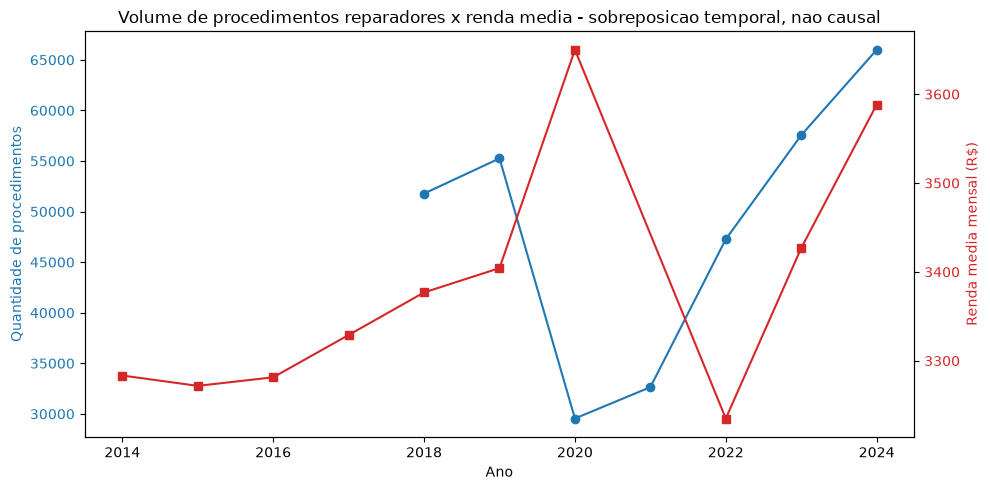

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(volume_total_ano.index, volume_total_ano.values, marker="o", color="tab:blue", label="Volume reparadores")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Quantidade de procedimentos", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
contexto_indexado = contexto_socioeconomico_brasil.set_index("ano")["renda_media_reais"]
ax2.plot(contexto_indexado.index, contexto_indexado.values, marker="s", color="tab:red", label="Renda media (R$)")
ax2.set_ylabel("Renda media mensal (R$)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Volume de procedimentos reparadores x renda media - sobreposicao temporal, nao causal")
plt.tight_layout()
plt.show()

## 8. Verificação final no Postgres

Confere direto na fonte (não confiando no "sem erro" da gravação): lista as tabelas do schema `gold` e mostra a contagem de linhas de cada uma.

In [16]:
with engine.connect() as conn:
    tabelas_pg = conn.execute(text(
        "SELECT table_name FROM information_schema.tables WHERE table_schema = :schema ORDER BY table_name"
    ), {"schema": PG_SCHEMA}).fetchall()

print(f"Tabelas no schema '{PG_SCHEMA}':")
for (nome,) in tabelas_pg:
    with engine.connect() as conn:
        total = conn.execute(text(f'SELECT COUNT(*) FROM {PG_SCHEMA}."{nome}"')).scalar()
    print(f" - {nome}: {total} linhas")

Tabelas no schema 'gold':
 - classificacao_procedimentos_reparadores: 54 linhas
 - contexto_socioeconomico_brasil: 10 linhas
 - procedimentos_reparadores_sus: 70 linhas


In [17]:
with engine.connect() as conn:
    amostra = pd.read_sql(text(f'SELECT * FROM {PG_SCHEMA}."procedimentos_reparadores_sus" ORDER BY ano DESC, categoria LIMIT 10'), conn)
amostra

,categoria,ano,origem,quantidade,valor_total_reais
0,Craniofacial-Fissura Labiopalatina,2024,hospitalar,6358.0,9356012.25
1,Ginecomastia,2024,hospitalar,2.0,1289.34
2,Mama,2024,ambulatorial,68.0,NaN
3,Mama,2024,hospitalar,14922.0,24559606.36
4,Nariz-Septo,2024,hospitalar,1674.0,846767.26
5,Orelha,2024,hospitalar,1712.0,859725.76
6,Palpebra,2024,hospitalar,5338.0,4457114.04
7,Palpebra,2024,ambulatorial,12147.0,NaN
8,Pos-bariatrica,2024,hospitalar,2899.0,2642417.03
9,Queimaduras,2024,hospitalar,20877.0,10752924.94


## 9. Conclusões

- **Classificação aplicada e auditável**: `classificacao_procedimentos_reparadores` documenta cada código incluído e por qual regra (explícita ou subgrupo `0404030`).
- **Tabela fato compacta**: `procedimentos_reparadores_sus` (categoria × ano × origem) já pronta para os gráficos e para consumo em ferramenta de BI, sem precisar refazer a filtragem/agregação a cada uso.
- **Contexto socioeconômico** trazido só na granularidade necessária (ano), não uma cópia integral da Silver do IBGE.
- **Publicado em dois destinos**: MinIO (bucket `gold`) para o data lake, Postgres (schema `gold`) para consumo relacional/BI — confirmado por leitura direta do Postgres, não pela ausência de erro na gravação.